In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
#Load Dataset

df = pd.read_csv("HousePricePrediction.csv")

df.head()

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0


In [3]:
# Dataset Overview
print("Shape:", df.shape)

df.info()

Shape: (2919, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            2919 non-null   int64  
 1   MSSubClass    2919 non-null   int64  
 2   MSZoning      2915 non-null   object 
 3   LotArea       2919 non-null   int64  
 4   LotConfig     2919 non-null   object 
 5   BldgType      2919 non-null   object 
 6   OverallCond   2919 non-null   int64  
 7   YearBuilt     2919 non-null   int64  
 8   YearRemodAdd  2919 non-null   int64  
 9   Exterior1st   2918 non-null   object 
 10  BsmtFinSF2    2918 non-null   float64
 11  TotalBsmtSF   2918 non-null   float64
 12  SalePrice     1460 non-null   float64
dtypes: float64(3), int64(6), object(4)
memory usage: 296.6+ KB


In [4]:
# Statistical Summary
df.describe()

,Id,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,SalePrice
count,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2918.000000,2918.000000,1460.000000
mean,1459.000000,57.137718,10168.114080,5.564577,1971.312778,1984.264474,49.582248,1051.777587,180921.195890
std,842.787043,42.517628,7886.996359,1.113131,30.291442,20.894344,169.205611,440.766258,79442.502883
min,0.000000,20.000000,1300.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,34900.000000
25%,729.500000,20.000000,7478.000000,5.000000,1953.500000,1965.000000,0.000000,793.000000,129975.000000
50%,1459.000000,50.000000,9453.000000,5.000000,1973.000000,1993.000000,0.000000,989.500000,163000.000000
75%,2188.500000,70.000000,11570.000000,6.000000,2001.000000,2004.000000,0.000000,1302.000000,214000.000000
max,2918.000000,190.000000,215245.000000,9.000000,2010.000000,2010.000000,1526.000000,6110.000000,755000.000000


In [5]:
# Check Missing Values
missing = df.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(ascending=False)

SalePrice      1459
MSZoning          4
Exterior1st       1
BsmtFinSF2        1
TotalBsmtSF       1
dtype: int64

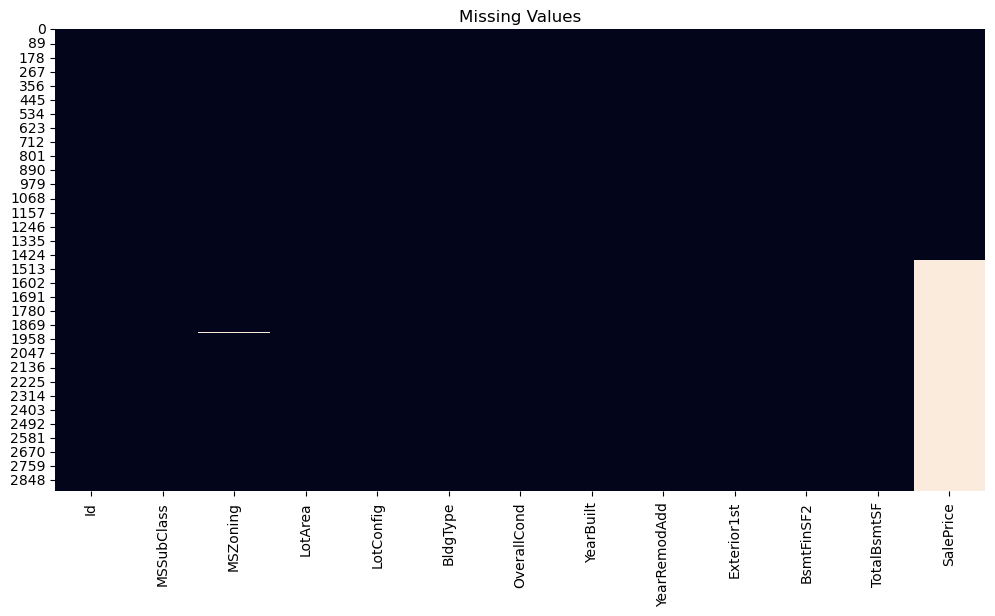

In [6]:
# Visualize Missing Values

plt.figure(figsize=(12,6))

sns.heatmap(
    df.isnull(),
    cbar=False
)

plt.title("Missing Values")
plt.show()

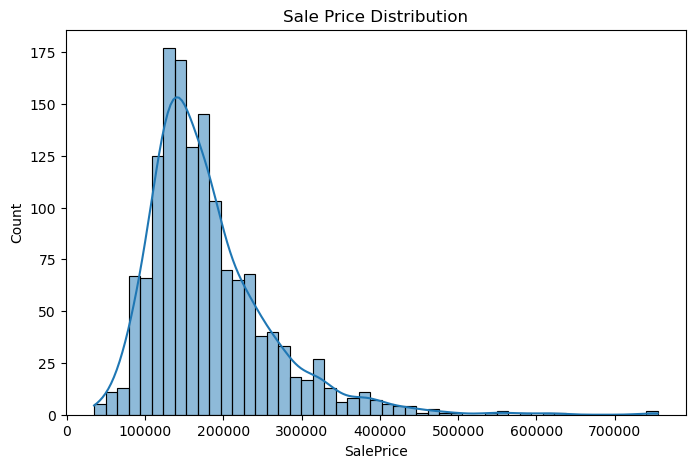

In [7]:
# Target Variable Distribution
plt.figure(figsize=(8,5))

sns.histplot(
    df["SalePrice"],
    kde=True
)

plt.title("Sale Price Distribution")

plt.show()

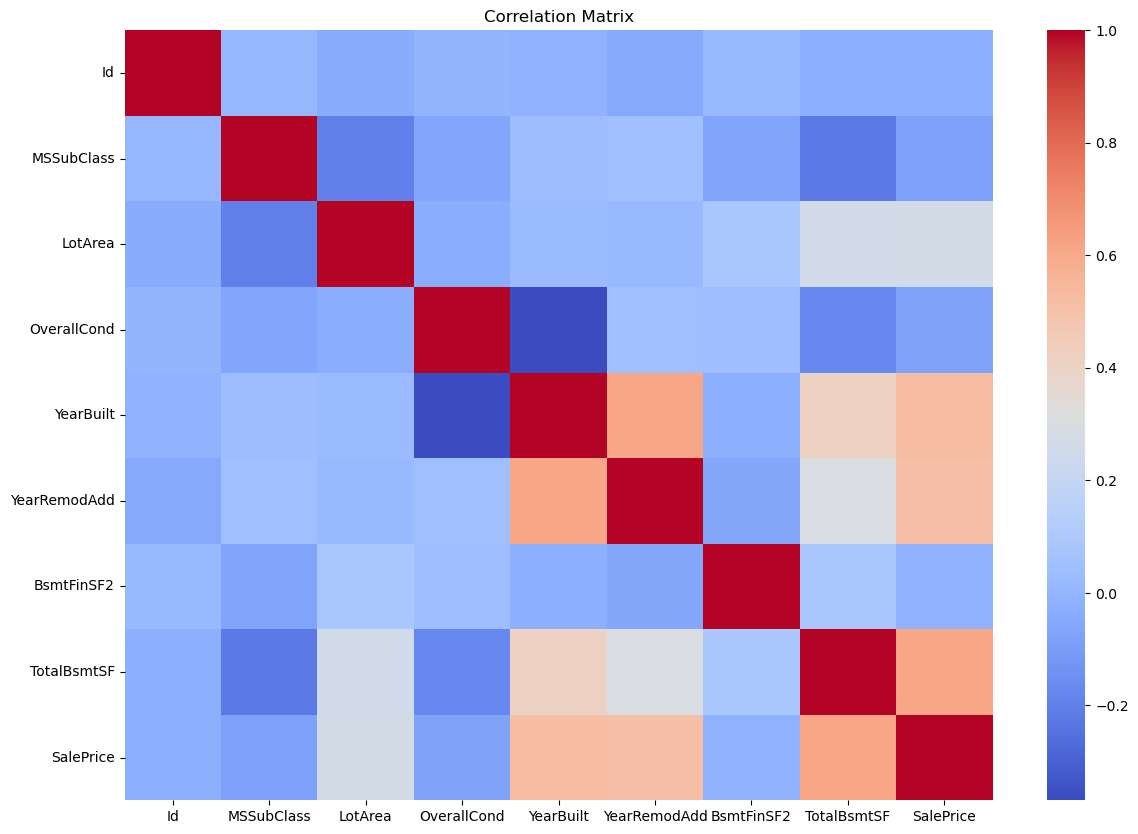

In [8]:
# Correlation Heatmap

plt.figure(figsize=(14,10))

corr = df.select_dtypes(
    include=np.number
).corr()

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [9]:
# Top Correlations With SalePrice
corr_target = corr["SalePrice"]

corr_target.sort_values(
    ascending=False
).head(15)

SalePrice       1.000000
TotalBsmtSF     0.613581
YearBuilt       0.522897
YearRemodAdd    0.507101
LotArea         0.263843
BsmtFinSF2     -0.011378
Id             -0.021917
OverallCond    -0.077856
MSSubClass     -0.084284
Name: SalePrice, dtype: float64

In [10]:
# Create Features and Target
df = pd.read_csv("HousePricePrediction.csv")

df = df.dropna(subset=["SalePrice"])

X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

print(X.shape)
print(y.shape)

(1460, 12)
(1460,)


In [11]:
# Separate Numeric and Categorical Columns

numeric_cols = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_cols = X.select_dtypes(
    include=["object"]
).columns

print("Numeric Columns:", len(numeric_cols))
print("Categorical Columns:", len(categorical_cols))

Numeric Columns: 8
Categorical Columns: 4


In [12]:
# Numeric Pipeline

numeric_transformer = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    )
])

In [13]:
# Categorical Pipeline

categorical_transformer = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="most_frequent"
        )
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

In [14]:
# Combine Preprocessing
preprocessor = ColumnTransformer([
    (
        "num",
        numeric_transformer,
        numeric_cols
    ),
    (
        "cat",
        categorical_transformer,
        categorical_cols
    )
])

In [15]:
# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(1168, 12)
(292, 12)


In [16]:
# Create Random Forest Model

rf = RandomForestRegressor(
    random_state=42
)

In [17]:
# Create Full Pipeline

model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "regressor",
        rf
    )
])

model

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [18]:
# Cross Validation

scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print(scores)
print(scores.mean())

[0.77214055 0.75763567 0.78969895 0.7777152  0.66130011]
0.7516980955187895


In [19]:
# Hyperparameter Grid
param_grid = {
    "regressor__n_estimators": [100, 200, 300],
    "regressor__max_depth": [10, 20, None],
    "regressor__min_samples_split": [2, 5, 10]
}

In [20]:
# Grid Search
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(
    X_train,
    y_train
)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'regressor__max_depth': [10, 20, ...], 'regressor__min_samples_split': [2, 5, ...], 'regressor__n_estimators': [100, 200, ...]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [21]:
# Best Parameters
print("Best Parameters:")

grid_search.best_params_

Best Parameters:


{'regressor__max_depth': None,
 'regressor__min_samples_split': 2,
 'regressor__n_estimators': 300}

In [22]:
# Best Model
best_model = grid_search.best_estimator_

best_model

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [23]:
# Predictions
pred = best_model.predict(
    X_test
)

pred[:10]

array([152560.16666667, 281706.00666667, 128932.55333333, 134245.98      ,
       280322.36      ,  96107.87333333, 246512.        , 139220.23333333,
        94267.52666667, 168076.32333333])

In [24]:
# MAE
mae = mean_absolute_error(
    y_test,
    pred
)

print("MAE:", mae)

MAE: 23474.501061643834


In [25]:
# RMSE
rmse = np.sqrt(
    mean_squared_error(
        y_test,
        pred
    )
)

print("RMSE:", rmse)

RMSE: 38061.006930292104


In [26]:
# R² Score
r2 = r2_score(y_test, pred)

joblib.dump(r2, "r2_score.pkl")
print("R2 Score:", r2)

R2 Score: 0.8111370743019558


In [27]:
from sklearn.linear_model import LinearRegression

lr_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

lr_r2 = r2_score(y_test, lr_pred)

rf_pred = best_model.predict(X_test)

rf_r2 = r2_score(y_test, rf_pred)

print("Linear Regression R²:", round(lr_r2,4))
print("Random Forest R²:", round(rf_r2,4))

Linear Regression R²: 0.6196
Random Forest R²: 0.8111


In [28]:
# Feature Importance

preprocessor = best_model.named_steps["preprocessor"]

feature_names = preprocessor.get_feature_names_out()

importances = best_model.named_steps["regressor"].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(15)

,Feature,Importance
4,num__YearBuilt,0.321312
7,num__TotalBsmtSF,0.307985
2,num__LotArea,0.154966
1,num__MSSubClass,0.051791
5,num__YearRemodAdd,0.045389
0,num__Id,0.030024
3,num__OverallCond,0.029400
36,cat__Exterior1st_Wd Sdng,0.012398
26,cat__Exterior1st_BrkFace,0.008918
35,cat__Exterior1st_VinylSd,0.004005


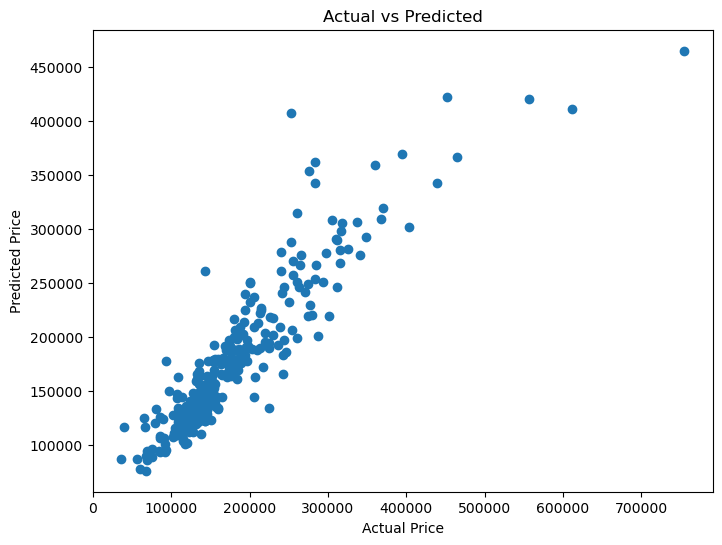

In [29]:
# Actual vs Predicted Plot
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    pred
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title(
    "Actual vs Predicted"
)

plt.show()

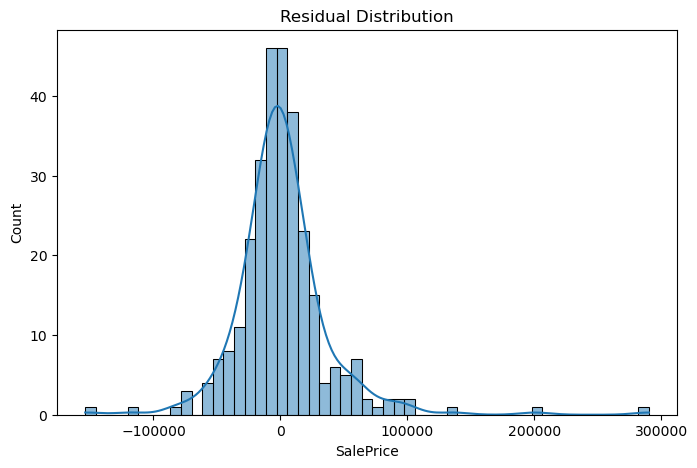

In [30]:
# Residual Analysis
residuals = y_test - pred

plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    kde=True
)

plt.title(
    "Residual Distribution"
)

plt.show()

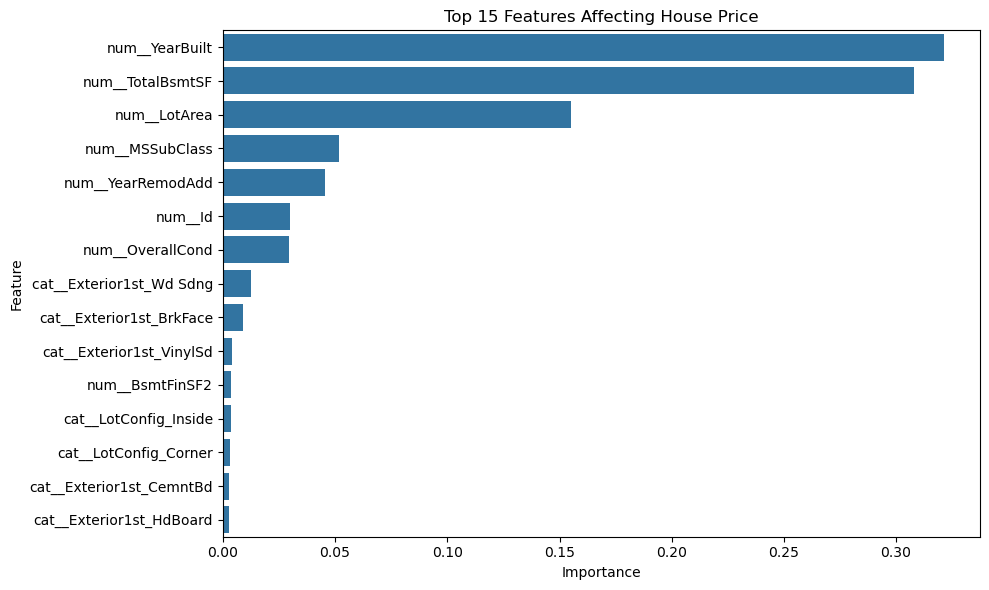

In [31]:
plt.figure(figsize=(10,6))

top_features = importance_df.head(15)

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Features Affecting House Price")

plt.tight_layout()

plt.show()

In [32]:
# Feature Importance
feature_names = best_model.named_steps[
    "preprocessor"
].get_feature_names_out()

importance = best_model.named_steps[
    "regressor"
].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(15)

,Feature,Importance
4,num__YearBuilt,0.321312
7,num__TotalBsmtSF,0.307985
2,num__LotArea,0.154966
1,num__MSSubClass,0.051791
5,num__YearRemodAdd,0.045389
0,num__Id,0.030024
3,num__OverallCond,0.029400
36,cat__Exterior1st_Wd Sdng,0.012398
26,cat__Exterior1st_BrkFace,0.008918
35,cat__Exterior1st_VinylSd,0.004005


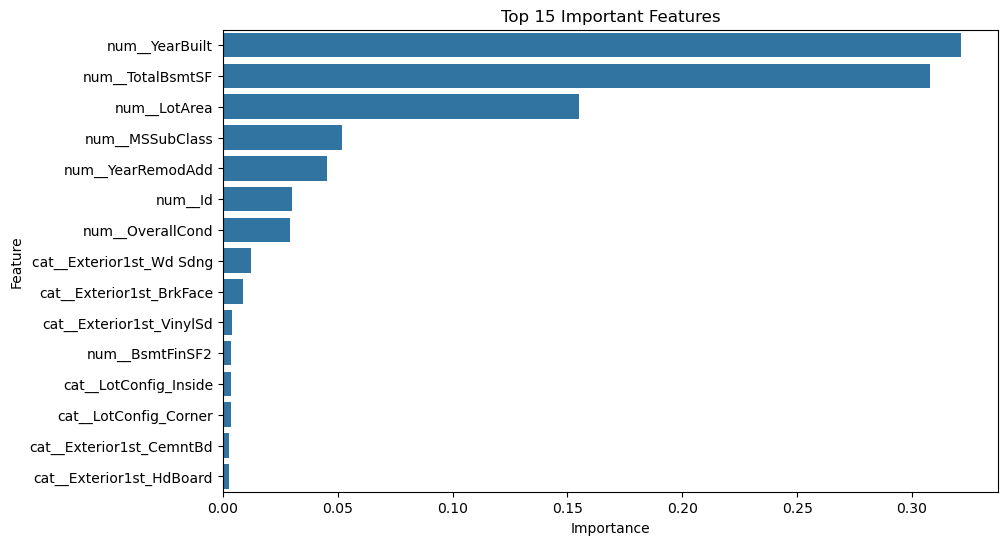

In [33]:
# Feature Importance Plot
top_features = importance_df.head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 15 Important Features"
)

plt.show()

In [34]:
# Predict One House
sample = X.iloc[[0]]

prediction = best_model.predict(
    sample
)

print(
    "Predicted Price:",
    prediction[0]
)

Predicted Price: 203579.96666666667


In [35]:
# Save Model
joblib.dump(
    best_model,
    "house_price_model.pkl"
)

print("Model Saved")

Model Saved


In [36]:
# Load Model
loaded_model = joblib.load(
    "house_price_model.pkl"
)

print("Model Loaded")

Model Loaded


In [37]:
# Test Loaded Model
loaded_model.predict(
    sample
)

array([203579.96666667])

In [38]:
# Tolist
print(X.columns.tolist())

['Id', 'MSSubClass', 'MSZoning', 'LotArea', 'LotConfig', 'BldgType', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'Exterior1st', 'BsmtFinSF2', 'TotalBsmtSF']


In [39]:
# Save Model
joblib.dump(
    best_model,
    "house_price_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


In [40]:
# Save Feature List
joblib.dump(
    X.columns.tolist(),
    "columns.pkl"
)

print("Columns Saved Successfully")

Columns Saved Successfully


In [41]:
# Create Streamlit App
app_code = '''
import streamlit as st
import pandas as pd
import joblib

model = joblib.load("house_price_model.pkl")
columns = joblib.load("columns.pkl")

st.set_page_config(
    page_title="House Price Predictor",
    page_icon="🏠",
    layout="centered"
)

st.title("🏠 House Price Prediction")

st.write(
    "Enter house details below"
)

# Important Features

lot_area = st.number_input(
    "Lot Area",
    min_value=1000,
    value=5000
)

overall_cond = st.slider(
    "Overall Condition",
    1,
    10,
    5
)

year_built = st.number_input(
    "Year Built",
    min_value=1900,
    max_value=2025,
    value=2000
)

year_remod = st.number_input(
    "Year Remodeled",
    min_value=1900,
    max_value=2025,
    value=2005
)

total_bsmt = st.number_input(
    "Total Basement Area",
    min_value=0,
    value=1000
)

ms_zoning = st.selectbox(
    "MS Zoning",
    [
        "RL",
        "RM",
        "FV",
        "RH",
        "C (all)"
    ]
)

bldg_type = st.selectbox(
    "Building Type",
    [
        "1Fam",
        "2fmCon",
        "Duplex",
        "Twnhs",
        "TwnhsE"
    ]
)

data = {}

for col in columns:
    data[col] = 0

# Populate important fields

if "LotArea" in columns:
    data["LotArea"] = lot_area

if "OverallCond" in columns:
    data["OverallCond"] = overall_cond

if "YearBuilt" in columns:
    data["YearBuilt"] = year_built

if "YearRemodAdd" in columns:
    data["YearRemodAdd"] = year_remod

if "TotalBsmtSF" in columns:
    data["TotalBsmtSF"] = total_bsmt

if "MSZoning" in columns:
    data["MSZoning"] = ms_zoning

if "BldgType" in columns:
    data["BldgType"] = bldg_type

if st.button("Predict House Price"):

    input_df = pd.DataFrame([data])

    prediction = model.predict(input_df)[0]

    lower = prediction * 0.9
    upper = prediction * 1.1

    st.success(
        f"Predicted House Price: ${prediction:,.2f}"
    )

    st.info(
        f"Estimated Range: ${lower:,.0f} - ${upper:,.0f}"
    )


r2 = 0.811
mae = 23475
rmse = 38061

st.subheader("Model Performance")

col1, col2, col3 = st.columns(3)

col1.metric("R² Score", f"{r2:.3f}")
col2.metric("MAE", f"${mae:,.0f}")
col3.metric("RMSE", f"${rmse:,.0f}")

st.caption(
    "Random Forest Regressor with Hyperparameter Tuning (GridSearchCV)"
)
'''

with open("app.py", "w", encoding="utf-8") as f:
    f.write(app_code)

print("app.py created successfully")

app.py created successfully


In [42]:
# Install Streamlit
!pip install streamlit

In [43]:
import sys
!{sys.executable} -m pip install streamlit

In [44]:
!pip uninstall scikit-learn -y
!pip install scikit-learn==1.5.2

Found existing installation: scikit-learn 1.5.2
Uninstalling scikit-learn-1.5.2:
  Successfully uninstalled scikit-learn-1.5.2
  Using cached scikit_learn-1.5.2-cp313-cp313-win_amd64.whl.metadata (13 kB)
Using cached scikit_learn-1.5.2-cp313-cp313-win_amd64.whl (11.0 MB)


In [45]:
import sklearn
print(sklearn.__version__)

1.7.1


In [46]:
# Verify
import streamlit

print(streamlit.__version__)

1.58.0


In [ ]:
# Run App
!streamlit run app.py